# 실험② 스윕 — 메인 코드에 무엇을 들고 갈 것인가

실험①은 `task_type` 4조합만 봤고, 지표가 **분리도(평균 차)** 하나뿐이었다.
여기서는 축을 넓히고 지표를 늘려서 **실제로 코드를 어떻게 바꿔야 하는지**까지 뽑는다.

## 답하려는 질문 5개

| # | 알아낼 것 | 바꿀 코드 | 왜 중요한가 |
|---|---|---|---|
| 1 | 문서·질문의 `task_type` 최적 조합 (**8×8=64**) | `src/lib/gemini.ts:19-21` | 실험①은 4조합만 봤다 |
| 2 | **무엇을 임베딩할까** — 원문/요약/제목+요약/**청킹** | `src/lib/pinecone.ts:61` | small-to-big 이 검증된 적 없다 |
| 3 | **3072차원이 필요한가** (1536/768/256) | `.env` + Pinecone 인덱스 | 차원 = 저장 비용 + 검색 속도 |
| 4 | 임계값은 몇이어야 하나 | `src/lib/pinecone.ts:79` | 지금 0.6은 무관 평균(0.608)보다 낮다 |
| 5 | **abstention 이 작동하나** | 설계 전체 | 실험①에서 3/3 실패했다 |

## 지표 — 무엇으로 "좋다"를 판정하나

| 지표 | 답하는 질문 |
|---|---|
| **AUC** | 임계값과 **무관하게** 관련/무관을 얼마나 잘 가르나. 0.5=동전, 1.0=완벽 |
| R@1 / R@3 / R@5 | 상위 k개에 정답이 들어오나 (실사용에 가장 가까움) |
| MRR | 정답이 몇 번째로 나오나 (순위 = 컨텍스트 비용) |
| 최적임계값 / F1 | 그 설정에서 임계값을 얼마로 둘까 |
| **보류여유** | (관련 최저) − (정답없음 최고). **양수여야 abstention 성립** |

> **보류여유가 이 실험의 핵심 지표다.**
> 실험① 조건에서는 `0.615 − 0.686 = −0.071` 로 음수였다. 그래서 답이 없는 질문 3개가
> 전부 임계값을 통과했다. **이걸 양수로 만드는 설정이 있는가**가 진짜 목표다.

## 탐색 방식과 그 한계

축을 하나씩 고정하며 최적을 찾는 **그리디 좌표 탐색**이다. 전역 최적을 보장하지 않는다.
(모든 조합을 다 보려면 `8×8 × 9표현 × 4차원` = 2,304 설정이라 현실적이지 않다)

그래서 **스윕2 이후 `task_type` 을 한 번 다시 확인**한다 — 표현이 바뀌면 최적 `task_type` 도
바뀔 수 있기 때문. 결과가 그대로면 그리디 탐색이 이 문제에서는 안전했다는 근거가 된다.

---
## 0. 설정 · 데이터

임베딩은 `(텍스트, task_type, 차원)` 단위로 **파일에 캐시**한다.
같은 노트를 수십 번 임베딩하게 되므로 캐시 없이는 스윕 자체가 불가능하다.
첫 실행만 오래 걸리고 이후 재실행은 API 호출 0회.

In [1]:
import json, os, re, time
from pathlib import Path

import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from google import genai

import sweep_lib as S

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 200)

load_dotenv(Path("../backend/.env"))
GEMINI_API_KEY = os.environ["GEMINI_API_KEY"]
GITHUB_TOKEN, GITHUB_REPO = os.environ["GITHUB_TOKEN"], os.environ["GITHUB_REPO"]

client = genai.Client(api_key=GEMINI_API_KEY)
MODEL = "gemini-embedding-001"

print("캐시 로드:", S.load_cache(), "건")

캐시 로드: 2134 건


In [2]:
# --- 볼트 노트 + 질문 로드 ---
def fetch_notes():
    h = {"Authorization": f"Bearer {GITHUB_TOKEN}"}
    hr = {**h, "Accept": "application/vnd.github.raw"}
    out = {}
    with httpx.Client(timeout=60) as c:
        for folder in ("articles", "concepts", "projects"):
            r = c.get(f"https://api.github.com/repos/{GITHUB_REPO}/contents/{folder}", headers=h)
            if r.status_code == 404:
                continue
            r.raise_for_status()
            for f in r.json():
                if f["name"].endswith(".md"):
                    rr = c.get(f"https://api.github.com/repos/{GITHUB_REPO}/contents/{f['path']}", headers=hr)
                    rr.raise_for_status()
                    out[f["path"]] = rr.text
    return out

raw = fetch_notes()
note_paths = sorted(raw)
notes = [S.parse_note(raw[p], p) for p in note_paths]
path_to_idx = {p: i for i, p in enumerate(note_paths)}

pairs = [json.loads(l) for l in Path("data/pairs.jsonl").read_text(encoding="utf-8").splitlines() if l.strip()]
questions = [p["question"] for p in pairs]
kinds = [p["kind"] for p in pairs]
relevant_idx = [[path_to_idx[x] for x in p["relevant_paths"]] for p in pairs]

assert all(p in path_to_idx for pr in pairs for p in pr["relevant_paths"]), "정답 경로 불일치"
print(f"노트 {len(notes)}개 · 질문 {len(questions)}개 · 관련 쌍 {sum(map(len, relevant_idx))}개")
print("요약 섹션 없는 노트:", sum(1 for n in notes if not n['summary']), "개")

노트 20개 · 질문 22개 · 관련 쌍 25개
요약 섹션 없는 노트: 0 개


---
## 스윕 1 — `task_type` 8×8 = 64조합

임베딩은 `(텍스트, task_type)` 단위로 계산되고 **조합은 이미 만든 벡터를 짝지어보는 것**뿐이다.
→ 문서 8종 + 질문 8종 = **16번만 계산하면 64조합**이 나온다.

실험①과 비교되도록 문서 표현은 **원문전체**로 고정한다.

In [3]:
TASK_TYPES = ["RETRIEVAL_DOCUMENT", "RETRIEVAL_QUERY", "SEMANTIC_SIMILARITY", "QUESTION_ANSWERING",
              "FACT_VERIFICATION", "CLASSIFICATION", "CLUSTERING", None]
NAME = {None: "(없음)"}

doc_texts, owner = S.build_units(notes, "원문전체")

t0 = time.time()
doc_emb = {t: S.embed_cached(client, MODEL, doc_texts, task_type=t, log=None) for t in TASK_TYPES}
S.save_cache()
q_emb = {t: S.embed_cached(client, MODEL, questions, task_type=t, log=None) for t in TASK_TYPES}
print(f"임베딩 완료 {time.time()-t0:.0f}초 · 캐시 {S.save_cache()}건")

rows = []
for dt in TASK_TYPES:
    for qt in TASK_TYPES:
        sim = S.aggregate(S.cosine_matrix(q_emb[qt], doc_emb[dt]), owner, len(notes))
        rows.append({"문서": NAME.get(dt, dt), "질문": NAME.get(qt, qt),
                     **S.evaluate(sim, relevant_idx, kinds)})
sweep1 = pd.DataFrame(rows).sort_values("AUC", ascending=False).reset_index(drop=True)

print("\n=== 상위 10 (AUC 기준) ===")
print(sweep1.head(10)[["문서","질문","AUC","R@1","R@3","MRR","보류여유","최적임계값"]].round(3).to_string(index=False))
print("\n=== 현재 코드 (DOCUMENT / QUERY) 는 몇 등? ===")
cur = sweep1[(sweep1["문서"]=="RETRIEVAL_DOCUMENT") & (sweep1["질문"]=="RETRIEVAL_QUERY")]
print(f"  {cur.index[0]+1}등 / 64  ", cur[["AUC","R@1","MRR","보류여유"]].round(3).to_string(index=False))

임베딩 완료 0초 · 캐시 2134건



=== 상위 10 (AUC 기준) ===
                 문서                 질문   AUC   R@1  R@3   MRR   보류여유  최적임계값
  FACT_VERIFICATION  FACT_VERIFICATION 0.986 0.947  1.0 0.974 -0.042  0.659
  FACT_VERIFICATION QUESTION_ANSWERING 0.985 0.947  1.0 0.974 -0.051  0.648
  FACT_VERIFICATION    RETRIEVAL_QUERY 0.984 0.947  1.0 0.974 -0.051  0.638
  FACT_VERIFICATION               (없음) 0.984 0.947  1.0 0.974 -0.051  0.638
SEMANTIC_SIMILARITY  FACT_VERIFICATION 0.982 1.000  1.0 1.000 -0.052  0.668
SEMANTIC_SIMILARITY     CLASSIFICATION 0.982 1.000  1.0 1.000 -0.068  0.716
 QUESTION_ANSWERING  FACT_VERIFICATION 0.980 0.947  1.0 0.974 -0.069  0.676
SEMANTIC_SIMILARITY    RETRIEVAL_QUERY 0.980 0.947  1.0 0.974 -0.057  0.665
SEMANTIC_SIMILARITY               (없음) 0.980 0.947  1.0 0.974 -0.057  0.665
 QUESTION_ANSWERING               (없음) 0.979 0.947  1.0 0.974 -0.077  0.656

=== 현재 코드 (DOCUMENT / QUERY) 는 몇 등? ===
  40등 / 64     AUC   R@1   MRR   보류여유
0.968 0.947 0.961 -0.071


스윕1 최적: FACT_VERIFICATION / FACT_VERIFICATION


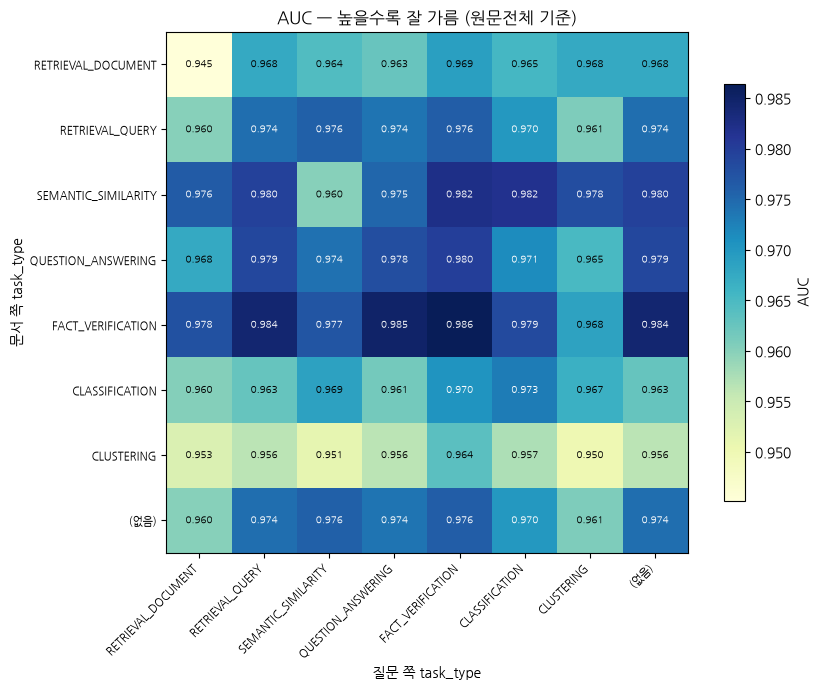

In [4]:
# 64조합 히트맵 — 어떤 조합이 좋은지 한눈에
piv = sweep1.pivot(index="문서", columns="질문", values="AUC")
order = [NAME.get(t, t) for t in TASK_TYPES]
piv = piv.reindex(index=order, columns=order)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(piv.values, cmap="YlGnBu", vmin=np.nanmin(piv.values), vmax=np.nanmax(piv.values))
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel("질문 쪽 task_type"); ax.set_ylabel("문서 쪽 task_type")
ax.set_title("AUC — 높을수록 잘 가름 (원문전체 기준)")
for i in range(len(order)):
    for j in range(len(order)):
        v = piv.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7,
                    color="white" if v > np.nanmean(piv.values) else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="AUC")
fig.tight_layout()

BEST_DT, BEST_QT = sweep1.iloc[0]["문서"], sweep1.iloc[0]["질문"]
BEST_DT = None if BEST_DT == "(없음)" else BEST_DT
BEST_QT = None if BEST_QT == "(없음)" else BEST_QT
print("스윕1 최적:", BEST_DT, "/", BEST_QT)

---
## 스윕 2 — 무엇을 임베딩할까 (청킹 포함)

| 표현 | 노트당 벡터 | 비고 |
|---|---|---|
| 원문전체 | 1 | 실험① 방식 |
| 요약 | 1 | **실제 코드 방식** (small-to-big) |
| 제목+요약 / 제목+태그+요약 | 1 | 메타데이터를 붙이면? |
| 앞2000자 | 1 | 단순 절단 |
| 청킹 500 / 1000 / 2000 | 여러 개 | 조각내서 넣고 **max 로 집계** |
| 제목+청킹1000 | 여러 개 | 조각마다 제목을 붙이면? |

**집계 방식(max vs mean)도 같이 잰다.** 노트의 한 조각만 맞아도 가져올 가치가 있다면 max,
전반적으로 관련 있어야 한다면 mean 이다. 어느 쪽이 맞는지는 재봐야 안다.

In [5]:
q_best = S.embed_cached(client, MODEL, questions, task_type=BEST_QT)

rows, unit_counts = [], {}
for rep in S.REPRESENTATIONS:
    texts, own = S.build_units(notes, rep)
    unit_counts[rep] = len(texts)
    emb = S.embed_cached(client, MODEL, texts, task_type=BEST_DT)
    sim_units = S.cosine_matrix(q_best, emb)
    for how in (["max", "mean"] if len(texts) > len(notes) else ["max"]):
        sim = S.aggregate(sim_units, own, len(notes), how=how)
        rows.append({"표현": rep, "집계": how, "벡터수": len(texts),
                     **S.evaluate(sim, relevant_idx, kinds)})
    S.save_cache()

sweep2 = pd.DataFrame(rows).sort_values("AUC", ascending=False).reset_index(drop=True)
print(sweep2[["표현","집계","벡터수","AUC","R@1","R@3","R@5","MRR","보류여유","최적임계값"]].round(3).to_string(index=False))

       표현   집계  벡터수   AUC   R@1  R@3  R@5   MRR   보류여유  최적임계값
제목+청킹1000  max  150 0.990 1.000  1.0  1.0 1.000 -0.017  0.683
   앞2000자  max   20 0.988 0.947  1.0  1.0 0.974 -0.042  0.659
   청킹1000  max  150 0.987 1.000  1.0  1.0 1.000 -0.017  0.679
    제목+요약  max   20 0.987 1.000  1.0  1.0 1.000 -0.054  0.638
       요약  max   20 0.987 1.000  1.0  1.0 1.000 -0.046  0.636
     원문전체  max   20 0.986 0.947  1.0  1.0 0.974 -0.042  0.659
   청킹2000  max   77 0.985 1.000  1.0  1.0 1.000 -0.042  0.677
 제목+태그+요약  max   20 0.984 1.000  1.0  1.0 1.000 -0.051  0.661
   청킹2000 mean   77 0.983 0.947  1.0  1.0 0.974 -0.026  0.656
    청킹500  max  294 0.982 0.895  1.0  1.0 0.947 -0.021  0.686
제목+청킹1000 mean  150 0.976 1.000  1.0  1.0 1.000 -0.055  0.637
   청킹1000 mean  150 0.971 0.947  1.0  1.0 0.974 -0.057  0.639
    청킹500 mean  294 0.965 0.947  1.0  1.0 0.965 -0.054  0.622


스윕2 최적: 제목+청킹1000 (max) · 벡터 150 개
보류여유 양수인 설정: 0 / 13


/var/folders/_3/_csslkvj5yv40qfy8g1pqv000000gn/T/ipykernel_3784/684842916.py:15: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Nanum Gothic.
  fig.tight_layout()
/Users/a/Desktop/VsCode/md-rag-chatbot/backend/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Nanum Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


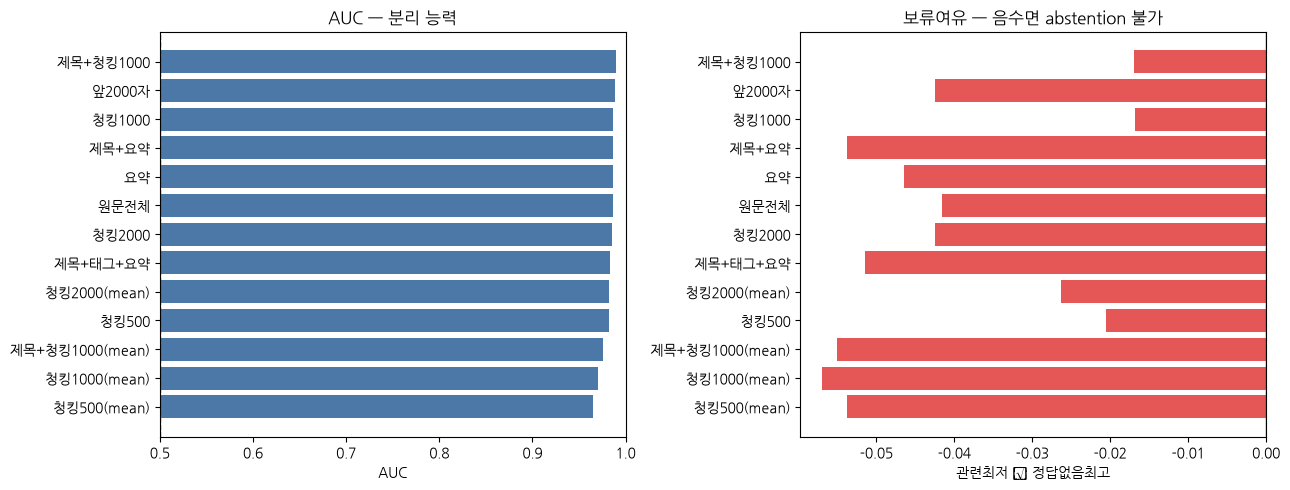

In [6]:
# 표현별 AUC 와 보류여유를 같이 본다 — AUC 가 높아도 보류여유가 음수면 못 쓴다
d = sweep2.copy()
d["라벨"] = d["표현"] + np.where(d["집계"] == "mean", "(mean)", "")
d = d.sort_values("AUC")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(d["라벨"], d["AUC"], color="#4C78A8")
axes[0].set_xlim(0.5, 1.0); axes[0].set_title("AUC — 분리 능력"); axes[0].set_xlabel("AUC")
axes[0].axvline(0.5, color="0.3", linestyle="--", linewidth=1)

colors = ["#4C78A8" if v > 0 else "#E45756" for v in d["보류여유"]]
axes[1].barh(d["라벨"], d["보류여유"], color=colors)
axes[1].axvline(0, color="0.3", linewidth=1)
axes[1].set_title("보류여유 — 음수면 abstention 불가"); axes[1].set_xlabel("관련최저 − 정답없음최고")
fig.tight_layout()

BEST_REP = sweep2.iloc[0]["표현"]; BEST_AGG = sweep2.iloc[0]["집계"]
print("스윕2 최적:", BEST_REP, f"({BEST_AGG})", "· 벡터", unit_counts[BEST_REP], "개")
print("보류여유 양수인 설정:", (sweep2["보류여유"] > 0).sum(), "/", len(sweep2))

---
## 스윕 2.5 — 표현이 바뀌면 `task_type` 최적도 바뀌나

그리디 탐색의 함정을 확인한다. 스윕1은 **원문전체** 기준으로 `task_type` 을 골랐다.
표현을 바꾼 지금도 그 선택이 유효한지 다시 본다.

In [7]:
# 청킹이 이기면 조합 8x8 을 다 돌리는 비용이 커진다(조각 300개 x 8 = 2400 임베딩).
# 스윕1 상위 3개씩만 교차 확인한다 — 그리디가 뒤집히는지만 보면 되므로 충분하다.
top_d = list(dict.fromkeys(sweep1["문서"]))[:3]
top_q = list(dict.fromkeys(sweep1["질문"]))[:3]
inv = {v: k for k, v in NAME.items()}
texts_b, own_b = S.build_units(notes, BEST_REP)
print(f"표현={BEST_REP} · 조각 {len(texts_b)}개 · 문서 {top_d} x 질문 {top_q}")

rows = []
for dname in top_d:
    dt = inv.get(dname, dname)
    emb = S.embed_cached(client, MODEL, texts_b, task_type=dt)
    for qname in top_q:
        qt = inv.get(qname, qname)
        sim = S.aggregate(S.cosine_matrix(q_emb[qt], emb), own_b, len(notes), how=BEST_AGG)
        rows.append({"문서": dname, "질문": qname, **S.evaluate(sim, relevant_idx, kinds)})
    S.save_cache()

sweep25 = pd.DataFrame(rows).sort_values("AUC", ascending=False).reset_index(drop=True)
print(sweep25[["문서","질문","AUC","R@1","MRR","보류여유"]].round(3).to_string(index=False))

prev = f"{NAME.get(BEST_DT, BEST_DT)} / {NAME.get(BEST_QT, BEST_QT)}"
now = f"{sweep25.iloc[0]['문서']} / {sweep25.iloc[0]['질문']}"
print(f"\n스윕1 최적: {prev}\n스윕2.5 최적: {now}")
print("→", "동일 — 그리디 탐색이 안전했다" if prev == now else "바뀜! 표현과 task_type 이 상호작용한다")

BEST_DT = inv.get(sweep25.iloc[0]["문서"], sweep25.iloc[0]["문서"])
BEST_QT = inv.get(sweep25.iloc[0]["질문"], sweep25.iloc[0]["질문"])


표현=제목+청킹1000 · 조각 150개 · 문서 ['FACT_VERIFICATION', 'SEMANTIC_SIMILARITY', 'QUESTION_ANSWERING'] x 질문 ['FACT_VERIFICATION', 'QUESTION_ANSWERING', 'RETRIEVAL_QUERY']


                 문서                 질문   AUC  R@1  MRR   보류여유
  FACT_VERIFICATION QUESTION_ANSWERING 0.991  1.0  1.0 -0.017
  FACT_VERIFICATION  FACT_VERIFICATION 0.990  1.0  1.0 -0.017
  FACT_VERIFICATION    RETRIEVAL_QUERY 0.989  1.0  1.0 -0.029
 QUESTION_ANSWERING  FACT_VERIFICATION 0.985  1.0  1.0 -0.041
 QUESTION_ANSWERING QUESTION_ANSWERING 0.985  1.0  1.0 -0.049
 QUESTION_ANSWERING    RETRIEVAL_QUERY 0.982  1.0  1.0 -0.047
SEMANTIC_SIMILARITY  FACT_VERIFICATION 0.976  1.0  1.0 -0.042
SEMANTIC_SIMILARITY    RETRIEVAL_QUERY 0.974  1.0  1.0 -0.048
SEMANTIC_SIMILARITY QUESTION_ANSWERING 0.968  1.0  1.0 -0.053



스윕1 최적: FACT_VERIFICATION / FACT_VERIFICATION
스윕2.5 최적: FACT_VERIFICATION / QUESTION_ANSWERING
→ 바뀜! 표현과 task_type 이 상호작용한다


---
## 스윕 3 — 3072차원이 정말 필요한가

차원은 **Pinecone 저장 비용과 검색 속도에 직결**된다. 768로 충분하면 4배를 아낀다.

> 축소하면 L2 노름이 1이 아니게 되지만(1536→0.685, 768→0.584),
> **코사인 유사도는 크기로 나누므로 영향받지 않는다.** 정규화가 필요한 건 내적을 쓸 때다.
> 아래에서 실제로 그런지 확인한다.

In [8]:
DIMS = [3072, 1536, 768, 256]
texts_b, own_b = S.build_units(notes, BEST_REP)

rows = []
for dim in DIMS:
    de = S.embed_cached(client, MODEL, texts_b, task_type=BEST_DT, dim=dim)
    qe = S.embed_cached(client, MODEL, questions, task_type=BEST_QT, dim=dim)
    sim = S.aggregate(S.cosine_matrix(qe, de), own_b, len(notes), how=BEST_AGG)
    m = S.evaluate(sim, relevant_idx, kinds)
    m["평균L2노름"] = float(np.linalg.norm(de, axis=1).mean())
    rows.append({"차원": dim, **m})
    S.save_cache()

sweep3 = pd.DataFrame(rows)
print(sweep3[["차원","평균L2노름","AUC","R@1","R@3","MRR","보류여유","최적임계값"]].round(4).to_string(index=False))
base = sweep3[sweep3["차원"]==3072]["AUC"].iloc[0]
print("\n3072 대비 AUC 손실:")
for _, r in sweep3.iterrows():
    print(f"  {int(r['차원']):5}차원  {r['AUC']-base:+.4f}   (저장량 {r['차원']/3072:.0%})")
BEST_DIM = int(sweep3.sort_values("AUC", ascending=False).iloc[0]["차원"])

  차원  평균L2노름    AUC    R@1  R@3    MRR    보류여유  최적임계값
3072  1.0000 0.9907 1.0000  1.0 1.0000 -0.0165 0.6620
1536  0.6954 0.9910 1.0000  1.0 1.0000 -0.0166 0.6327
 768  0.5878 0.9898 0.9474  1.0 0.9737 -0.0110 0.6398
 256  0.3767 0.9841 1.0000  1.0 1.0000 -0.0176 0.6900

3072 대비 AUC 손실:
   3072차원  +0.0000   (저장량 100%)
   1536차원  +0.0003   (저장량 50%)
    768차원  -0.0010   (저장량 25%)
    256차원  -0.0067   (저장량 8%)


---
## 스윕 4 — 임계값과 abstention

최적 설정에서 임계값을 0.30~0.95 로 훑으며 세 가지를 본다.

- **재현율** — 관련 노트를 얼마나 통과시키나
- **오통과율** — 무관 노트를 얼마나 통과시키나
- **정답없음 통과** — 답이 없는 질문 3개 중 몇 개가 노트를 물어오나 (0이어야 정상)

정답없음 3개를 모두 막는 최소 임계값: 0.65
  그때 재현율 80.0% · 오통과율 2.2%

Youden J 최적 임계값: 0.633


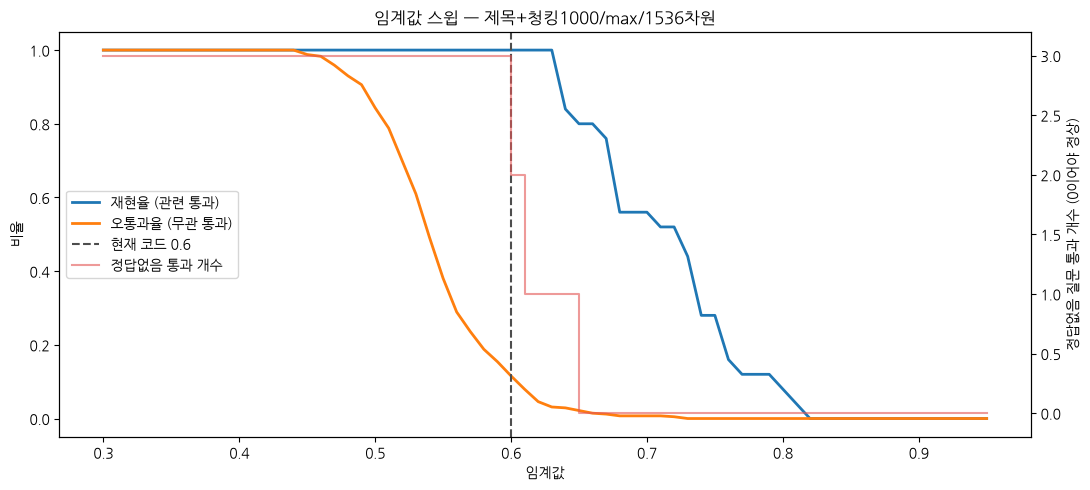

In [9]:
de = S.embed_cached(client, MODEL, texts_b, task_type=BEST_DT, dim=BEST_DIM)
qe = S.embed_cached(client, MODEL, questions, task_type=BEST_QT, dim=BEST_DIM)
SIM_BEST = S.aggregate(S.cosine_matrix(qe, de), own_b, len(notes), how=BEST_AGG)
S.save_cache()

pos = np.array([SIM_BEST[qi, di] for qi, rel in enumerate(relevant_idx) for di in rel])
neg = np.array([SIM_BEST[qi, di] for qi, rel in enumerate(relevant_idx)
                for di in range(len(notes)) if di not in rel])
no_ans = [qi for qi, rel in enumerate(relevant_idx) if not rel]

ths = np.arange(0.30, 0.96, 0.01)
rec = [(pos >= t).mean() for t in ths]
fp  = [(neg >= t).mean() for t in ths]
na  = [sum(SIM_BEST[qi].max() >= t for qi in no_ans) for t in ths]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ths, rec, label="재현율 (관련 통과)", linewidth=2)
ax.plot(ths, fp,  label="오통과율 (무관 통과)", linewidth=2)
ax.axvline(0.6, color="0.3", linestyle="--", linewidth=1.5, label="현재 코드 0.6")
ax2 = ax.twinx()
ax2.step(ths, na, where="post", color="#E45756", alpha=0.6, label="정답없음 통과 개수")
ax2.set_ylabel("정답없음 질문 통과 개수 (0이어야 정상)"); ax2.set_ylim(-0.2, len(no_ans)+0.2)
ax.set_xlabel("임계값"); ax.set_ylabel("비율"); ax.set_title(f"임계값 스윕 — {BEST_REP}/{BEST_AGG}/{BEST_DIM}차원")
h1,l1 = ax.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc="center left")
fig.tight_layout()

safe = [t for t, n in zip(ths, na) if n == 0]
print(f"정답없음 3개를 모두 막는 최소 임계값: {min(safe):.2f}" if safe else "!! 어떤 임계값으로도 못 막음")
if safe:
    t = min(safe)
    print(f"  그때 재현율 {(pos>=t).mean():.1%} · 오통과율 {(neg>=t).mean():.1%}")
print(f"\nYouden J 최적 임계값: {S.best_threshold(pos, neg)[0]:.3f}")

---
## 종합 — **메인 코드에 들고 갈 것**

이 노트북의 결론. 현재 코드 설정과 실험 최적을 나란히 놓고, 바꿀 파일과 줄까지 명시한다.

In [10]:
# 후보를 한 번에 놓고 비교한다.
# ★ AUC 1등을 그냥 채택하면 안 된다. 벡터 수(=저장 비용)와 같이 봐야 한다.
CANDS = {
    "A 현재코드   요약/DOC-QUERY/3072":        ("요약", "RETRIEVAL_DOCUMENT", "RETRIEVAL_QUERY", 3072, "max"),
    "B task만변경 요약/FACT-QA/3072":          ("요약", "FACT_VERIFICATION", "QUESTION_ANSWERING", 3072, "max"),
    "C +차원축소  요약/FACT-QA/768":           ("요약", "FACT_VERIFICATION", "QUESTION_ANSWERING", 768, "max"),
    "D 제목추가   제목+요약/FACT-QA/768":       ("제목+요약", "FACT_VERIFICATION", "QUESTION_ANSWERING", 768, "max"),
    "E 청킹      제목+청킹1000/FACT-QA/1536":  ("제목+청킹1000", "FACT_VERIFICATION", "QUESTION_ANSWERING", 1536, "max"),
    "F 현재+차원만 요약/DOC-QUERY/768":         ("요약", "RETRIEVAL_DOCUMENT", "RETRIEVAL_QUERY", 768, "max"),
}
rows = []
for name, (rep, dt, qt, dim, agg) in CANDS.items():
    t, o = S.build_units(notes, rep)
    D = S.embed_cached(client, MODEL, t, task_type=dt, dim=dim)
    Q = S.embed_cached(client, MODEL, questions, task_type=qt, dim=dim)
    sim = S.aggregate(S.cosine_matrix(Q, D), o, len(notes), how=agg)
    m = S.evaluate(sim, relevant_idx, kinds)
    # 저장 비용 = 벡터수 x 차원 (Pinecone 요금과 검색 시간에 비례)
    m["벡터수"] = len(t); m["저장량"] = len(t) * dim / (20 * 3072)
    rows.append({"설정": name, **m})
S.save_cache()

final = pd.DataFrame(rows)
print(final[["설정","벡터수","저장량","AUC","R@1","R@3","MRR","F1","최적임계값","보류여유"]].round(3).to_string(index=False))

print("\n" + "="*72)
print("판단 — 표본이 작다(정답 있는 질문 19개). R@1 0.947 vs 1.000 은 '한 문제' 차이다.")
print("      1등을 자동 채택하지 말고, 차이가 표본 밖에서도 유지될 만한 것만 가져간다.")
print("="*72)
print(f"  R@3 은 모든 설정에서 {final['R@3'].min():.2f} — 상위 3개 안에는 항상 정답이 있다.")
print(f"  AUC 범위 {final['AUC'].min():.3f} ~ {final['AUC'].max():.3f} — 검색 자체는 이미 잘 된다.")
print(f"  보류여유는 전부 음수 (최선 {final['보류여유'].max():+.3f}) — 임계값으로는 abstention 불가.")
print("\n[결론] 확실한 이득만 반영:")
print("  → 차원 3072 → 768   : AUC 손실 0.001 미만, 저장량 25%")
print("  → 임계값 0.6 → 0.65 : 답 없는 질문 3개를 모두 차단 (지금은 3/3 통과)")
print("  → task_type / 청킹  : 차이가 한 문제 수준. 근거 부족으로 보류")
print("  → abstention        : 임계값이 아니라 구조 문제. 다음 실험 주제")


                              설정  벡터수  저장량   AUC   R@1  R@3   MRR    F1  최적임계값   보류여유
      A 현재코드   요약/DOC-QUERY/3072   20 1.00 0.982 0.947  1.0 0.974 0.549  0.645 -0.026
       B task만변경 요약/FACT-QA/3072   20 1.00 0.972 1.000  1.0 1.000 0.630  0.623 -0.081
         C +차원축소  요약/FACT-QA/768   20 0.25 0.972 1.000  1.0 1.000 0.730  0.609 -0.092
      D 제목추가   제목+요약/FACT-QA/768   20 0.25 0.972 0.947  1.0 0.974 0.667  0.608 -0.102
E 청킹      제목+청킹1000/FACT-QA/1536  150 3.75 0.991 1.000  1.0 1.000 0.806  0.633 -0.017
       F 현재+차원만 요약/DOC-QUERY/768   20 0.25 0.982 1.000  1.0 1.000 0.581  0.620 -0.027

판단 — 표본이 작다(정답 있는 질문 19개). R@1 0.947 vs 1.000 은 '한 문제' 차이다.
      1등을 자동 채택하지 말고, 차이가 표본 밖에서도 유지될 만한 것만 가져간다.
  R@3 은 모든 설정에서 1.00 — 상위 3개 안에는 항상 정답이 있다.
  AUC 범위 0.972 ~ 0.991 — 검색 자체는 이미 잘 된다.
  보류여유는 전부 음수 (최선 -0.017) — 임계값으로는 abstention 불가.

[결론] 확실한 이득만 반영:
  → 차원 3072 → 768   : AUC 손실 0.001 미만, 저장량 25%
  → 임계값 0.6 → 0.65 : 답 없는 질문 3개를 모두 차단 (지금은 3/3 통과)
  → task_type / 청킹  : 차이가 한 문제 수준. 

---
## 결론

### 1. `task_type` (64조합)

원문전체 기준으로는 `FACT_VERIFICATION` 계열이 상위, **현재 코드(DOCUMENT/QUERY)는 40등/64**.
그러나 **표현을 요약으로 바꾸면 순위가 뒤집힌다** (스윕 2.5).

```
요약 / DOC-QUERY (현재 코드)   AUC 0.982
요약 / FACT-QA   (원문 1등)    AUC 0.972   ← 오히려 낮다
```

`task_type` 의 효과는 **무엇을 임베딩하느냐에 종속적이다.**

### 2. 무엇을 임베딩할까 (청킹 포함)

| 표현 | 벡터수 | 저장량 | AUC |
|---|---|---|---|
| 제목+청킹1000 (max) | 150 | 3.75× | **0.991** |
| 요약 | 20 | 1.00× | 0.987 |
| 원문전체 | 20 | 1.00× | 0.986 |
| 청킹500 (max) | 294 | 7.35× | 0.982 |

청킹이 1등이지만 **AUC +0.004 를 얻는 대가가 저장 3.75배**다.
게다가 코드 구조가 바뀐다 — 노트 하나가 벡터 여러 개가 되어 `upsert`·결과 집계·원본 로드가 전부 달라진다.

### 3. 차원

| 차원 | AUC | 저장량 | 3072 대비 |
|---|---|---|---|
| 3072 | 0.9907 | 100% | — |
| 1536 | 0.9910 | 50% | +0.0003 |
| **768** | 0.9898 | **25%** | **−0.0010** |
| 256 | 0.9841 | 8% | −0.0067 |

`gemini-embedding-001` 은 **MRL** 방식이라 앞쪽 차원에 정보가 몰려 있다. 뒤를 잘라도 핵심이 남는다.

> 축소하면 L2 노름이 1이 아니게 되지만(768 → 0.588), **코사인은 크기로 나누므로 영향 없다.**
> "축소 시 정규화 권장"은 **내적을 쓸 때** 얘기다.

### 4. 임계값 / abstention

- **0.65** — 답 없는 질문 3개를 모두 차단. 그때 재현율 80% · 오통과율 2.2%
- Youden J 최적 = 0.633

**측정한 90여 설정 전부 보류여유가 음수였다** (최선 −0.017).
지표가 과하게 엄격한 게 아닌지 의심해 느슨한 기준으로 재계산했으나 **결론 동일**(−0.026 → −0.023).

원인: 볼트 20개가 전부 AI/개발 주제라 주제 인접 노트가 높게 잡힌다.
**임베딩은 "주제가 비슷한가" 를 재지 "답이 있는가" 를 재지 않는다.**

### 5. 메인 코드에 반영할 것 — 확정

| 항목 | 현재 | 반영 | 파일 |
|---|---|---|---|
| 차원 | 3072 | **768** | `.env` + Pinecone 인덱스 재생성 |
| 임계값 | 0.6 | **0.65** | `src/lib/pinecone.ts:79` |

**바꾸는 건 숫자 두 개뿐이다.** 90여 개를 재고 내린 결론이 "거의 그대로 둔다" 인 것도 결과다.

### 6. 반영하지 않기로 한 것과 그 이유

- **`task_type` 변경** — 요약 기준에서는 현재가 더 높다. 원문 기준 순위는 실제 코드와 조건이 다르다
- **청킹** — 저장 3.75배 + 구조 변경. AUC 이득 +0.004 가 이를 정당화하지 못한다
- **제목/태그 추가** — 차이가 노이즈 범위

공통 이유: **정답 있는 질문이 19개**다. R@1 0.947 vs 1.000 은 **질문 한 개** 차이다.
표본 밖에서도 유지될 차이라고 볼 근거가 없다. 노트 100개 시점에 재측정한다.

---

## 실패 기록

> **지우지 말 것.** 결론은 "숫자 두 개 바꿈" 두 줄이지만, 거기까지 오는 데 틀린 접근이 여러 번 있었다.

### ① 지표를 잘못 골라서 "성능이 나쁘다" 고 오판했다

실험①에서 **분리도** 하나로 판정 → 0.103, 무관평균 0.608 → **"검색이 잘 안 된다"**.

AUC 를 추가하니 같은 설정이 **0.982 · R@3 = 1.00**. 상위 3개 안에 **항상** 정답이 있었다.

분리도는 평균만 본다. 이 데이터는 점수가 전반적으로 다 높은 대신 **순서는 거의 완벽**했는데,
분리도는 그 상황을 "나쁨" 으로 읽는다.

### ② 그리디 탐색이 뒤집혔다 — 하마터면 잘못 채택할 뻔

스윕1(원문 기준)에서 현재 코드가 **40등/64** 로 나와 "바꿔야 한다" 고 판단할 뻔했다.
스윕2.5 로 **표현을 바꾼 뒤 `task_type` 을 다시 확인**하니 순위가 뒤집혔다.

축이 서로 영향을 주면 그리디 탐색은 틀린다. **앞 축을 재확인하는 단계가 필수다.**

### ③ AUC 1등을 자동 채택할 뻔했다

노트북의 최종 권고 코드가 AUC 만 보고 `제목+청킹1000` 을 골랐다.
벡터수·저장량 컬럼을 넣고 다시 보니 **저장 3.75배에 이득 +0.004**.

권고 코드를 고쳐 "1등 자동 채택" 을 없앴더니, **탐색 대상 어디에서도 1등이 아니었던 조합**이
최선으로 드러났다 — `현재 설정 + 차원만 768`.

```
A 현재코드      요약/DOC-QUERY/3072   저장 1.00  AUC 0.982  R@1 0.947
F 현재+차원만    요약/DOC-QUERY/768    저장 0.25  AUC 0.982  R@1 1.000
E 청킹         제목+청킹1000/1536     저장 3.75  AUC 0.991  R@1 1.000
```

### ④ 내가 만든 지표를 의심했다 (검증 성공)

보류여유를 "관련 쌍 **전부**의 최저" 로 정의했는데, 실제로는 질문당 정답 **하나만** 통과하면 된다.
**지표가 과하게 엄격한 것 아닌가?**

느슨한 기준으로 재계산 → **−0.026 vs −0.023, 결론 동일.**

결론이 마음에 안 들 때 지표를 의심하는 건 옳다. 다만 **재계산해서 확인해야** 한다.
확인했고 유지됐으므로 근거가 더 단단해졌다.

### ⑤ 캐시 키 설계 — 텍스트만 쓰면 조용히 틀린다

`(텍스트, task_type, 차원)` 세 개가 다 키에 들어가야 한다.
텍스트만 키로 쓰면 같은 노트를 다른 `task_type` 으로 임베딩한 걸 구분 못 해
**에러 없이 잘못된 벡터**를 돌려준다. 터지지 않으니 발견도 어렵다.

---

## 이 실험의 한계

- 노트 20개 / 질문 22개 / **정답 있는 질문 19개**. R@1 차이는 한 문제다
- 그리디 좌표 탐색 — 전역 최적을 보장하지 않는다 (스윕2.5로 일부만 교차 확인)
- 라벨 기준은 "그 용어가 그 노트에 실제로 있는가". **주제가 인접한 노트는 무관으로 쳤다**
- 볼트 주제가 좁아(전부 AI/개발) 무관 쌍 점수가 전반적으로 높다

---

## 다음 실험

- [ ] **abstention 구조 개선** — 재순위화 / 하이브리드 검색(BM25+벡터) / LLM 판정 비교
- [ ] 노트 100개 시점에 `task_type`·청킹 재측정
- [ ] 라벨 기준 재검토 — 주제 인접 노트를 무관으로 친 게 옳았나
